In [1]:
#import libraies
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning - Dataset
from sklearn.datasets import load_iris

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Visualization settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6


In [2]:
# LOAD IRIS DATASET
# Load the iris dataset
iris = load_iris()

# Create a DataFrame for better visualization
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Add target column
df['species'] = iris.target

# Map target numbers to actual species names
species_mapping = {
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
}
df['species_name'] = df['species'].map(species_mapping)

# Display basic information
print("="*70)
print("IRIS DATASET LOADED SUCCESSFULLY")
print("="*70)
print(f"\n Dataset Shape: {df.shape}")
print(f"Total Samples: {len(df)}")
print(f"Total Features: {len(iris.feature_names)}")
print(f"Classes: {list(iris.target_names)}")
print("\n" + "="*70)

# Display first few rows
print("\n First 5 rows of the dataset:\n")
display(df.head(10))

IRIS DATASET LOADED SUCCESSFULLY

 Dataset Shape: (150, 6)
Total Samples: 150
Total Features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


 First 5 rows of the dataset:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [5]:
# DATASET INFORMATION

print("="*70)
print("DATASET INFORMATION")
print("="*70)

# Dataset info
print("\n Data Types and Non-Null Counts:")
print("-"*70)
df.info()

print("\n" + "="*70)
print("\n Statistical Summary:")
print("-"*70)
display(df.describe())

print("\n" + "="*70)
print("\n Missing Values Check:")
print("-"*70)
missing_values = df.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("\n No missing values found! Dataset is clean.")
else:
    print(f"\n Found {missing_values.sum()} missing values.")

print("\n" + "="*70)
print("\n Class Distribution:")
print("-"*70)
class_distribution = df['species_name'].value_counts()
print(class_distribution)
print(f"\n Dataset is perfectly balanced with {class_distribution.iloc[0]} samples per class.")

DATASET INFORMATION

 Data Types and Non-Null Counts:
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


 Statistical Summary:
----------------------------------------------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000




 Missing Values Check:
----------------------------------------------------------------------
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

 No missing values found! Dataset is clean.


 Class Distribution:
----------------------------------------------------------------------
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

 Dataset is perfectly balanced with 50 samples per class.


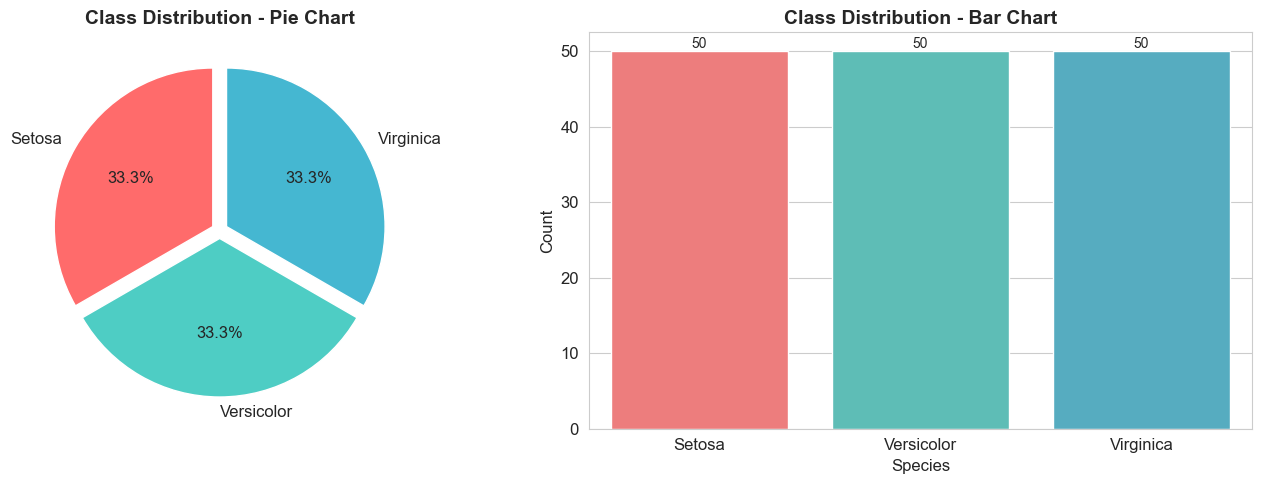

The dataset is perfectly balanced with 50 samples of each species.


In [6]:
# VISUALIZATION 1: CLASS DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].pie(
    df['species_name'].value_counts(),
    labels=df['species_name'].value_counts().index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05)
)
axes[0].set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(
    data=df,
    x='species_name',
    palette=colors,
    ax=axes[1]
)
axes[1].set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Species', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

# Add count labels on bars
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

print("The dataset is perfectly balanced with 50 samples of each species.")

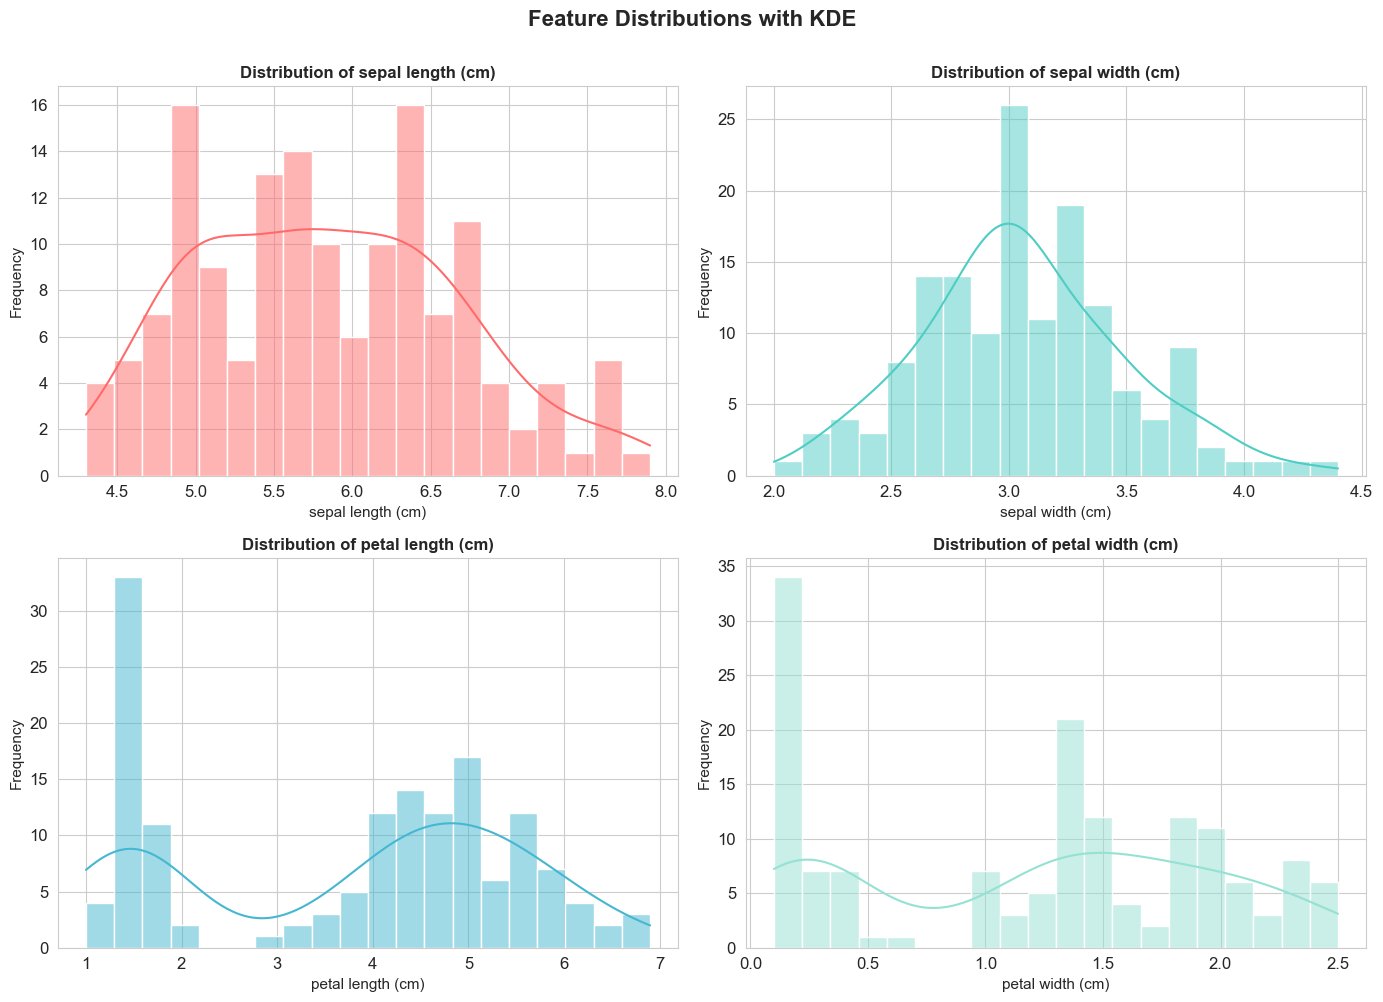

In [7]:
# VISUALIZATION 2: FEATURE DISTRIBUTIONS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = iris.feature_names
colors_dist = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3']

for idx, (ax, feature, color) in enumerate(zip(axes.flatten(), features, colors_dist)):
    # Histogram with KDE
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        color=color,
        ax=ax,
        bins=20
    )
    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)

plt.suptitle('Feature Distributions with KDE', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

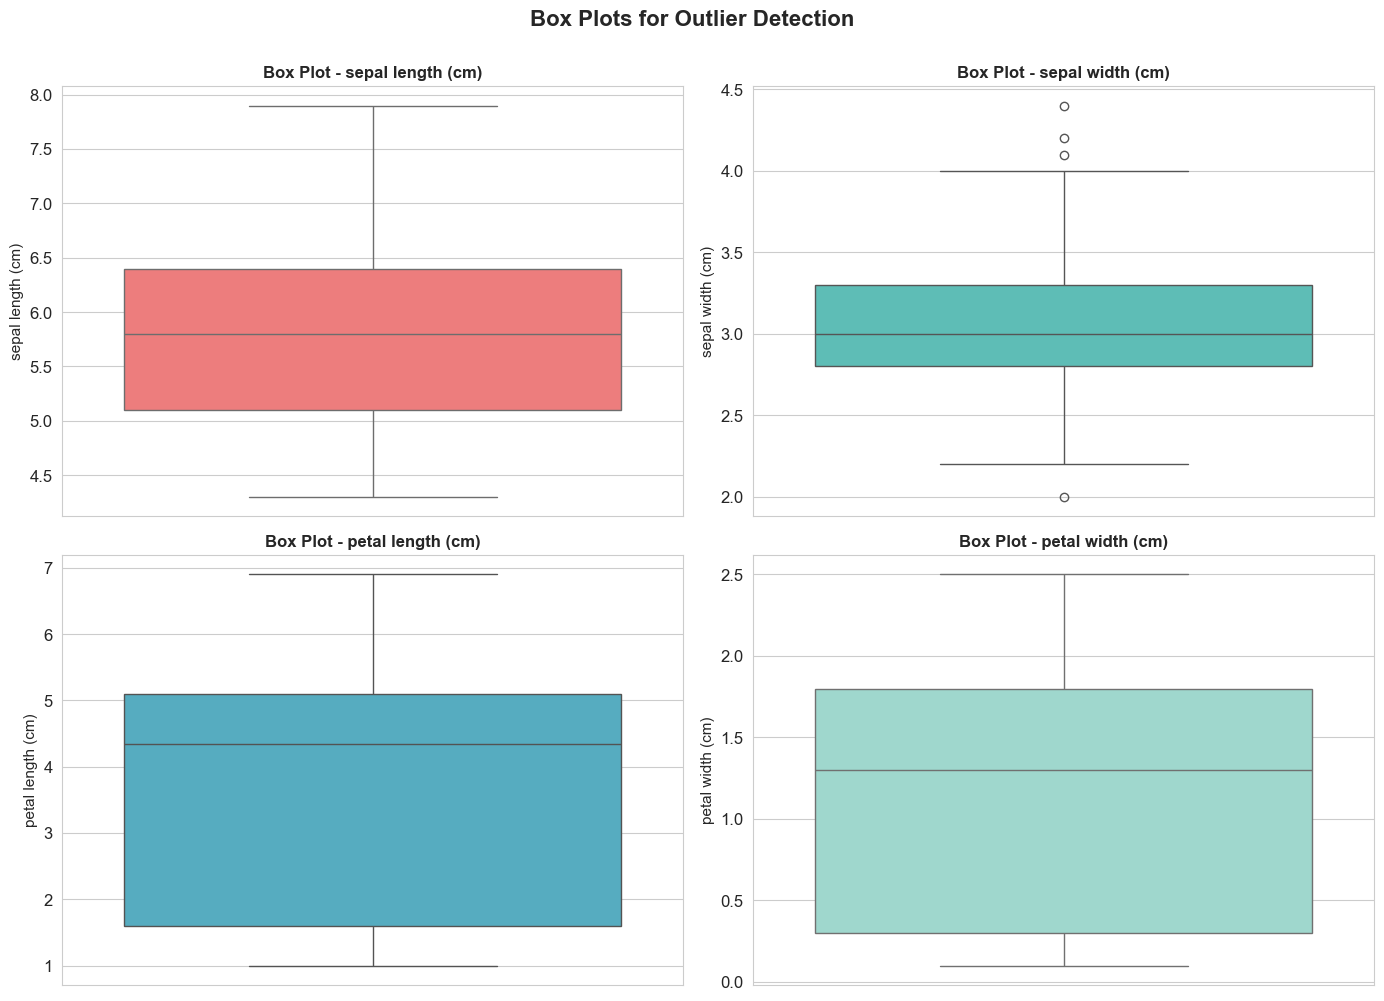

Box plots help identify potential outliers in the dataset.
Minor outliers detected, but they are natural variations in iris measurements.


In [8]:
# VISUALIZATION 3: BOX PLOTS (Outlier Detection)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = iris.feature_names
colors_box = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3']

for idx, (ax, feature, color) in enumerate(zip(axes.flatten(), features, colors_box)):
    sns.boxplot(
        data=df,
        y=feature,
        color=color,
        ax=ax
    )
    ax.set_title(f'Box Plot - {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature, fontsize=11)

plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Box plots help identify potential outliers in the dataset.")
print("Minor outliers detected, but they are natural variations in iris measurements.")

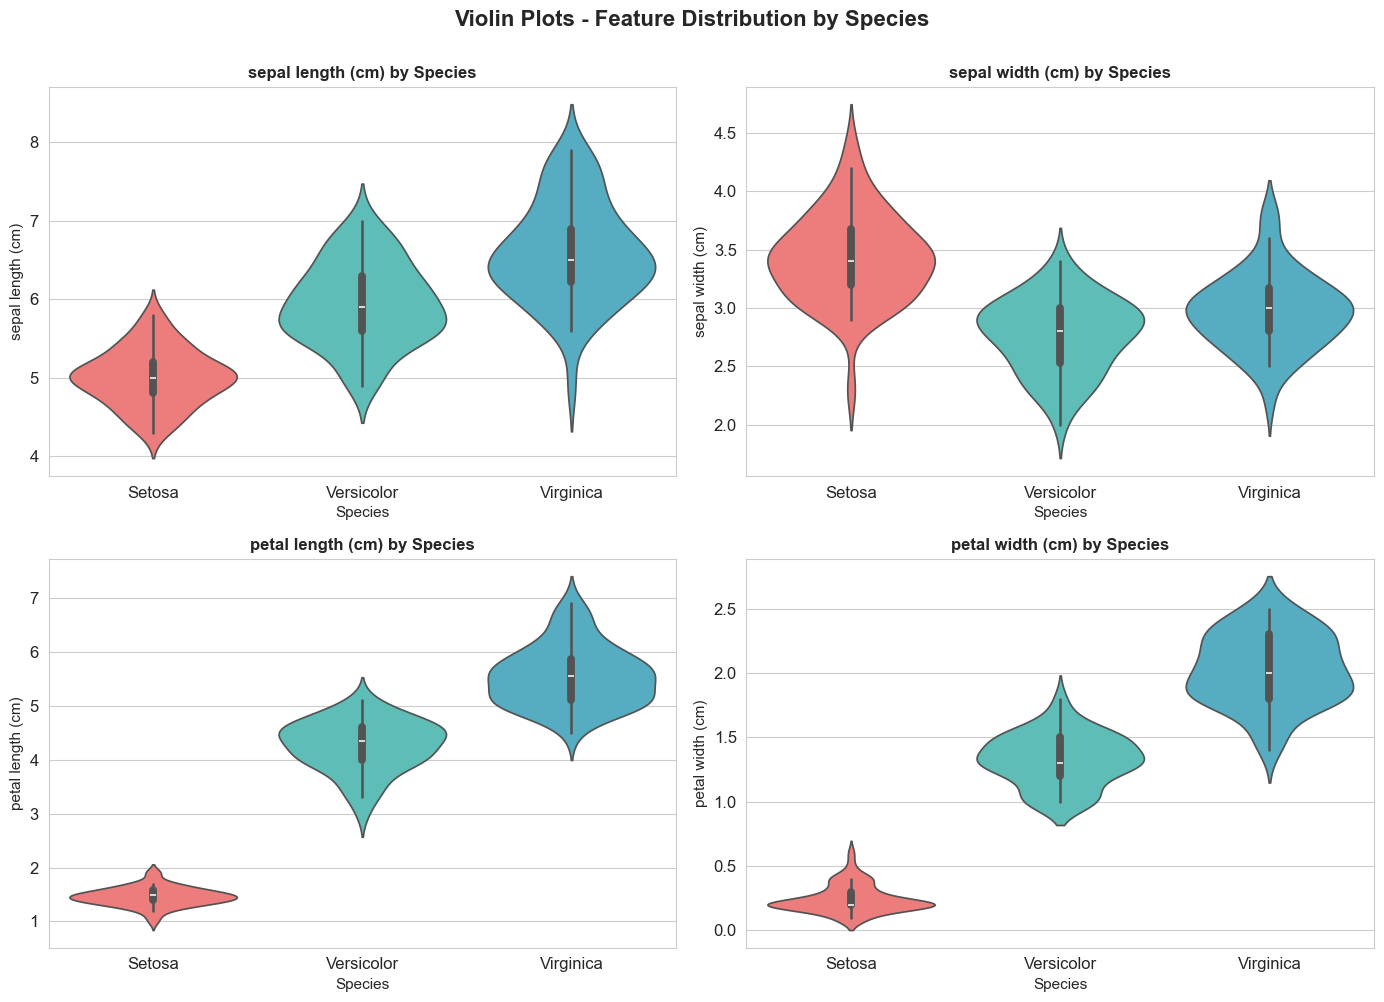

 Key Observations:
   • Setosa has distinctly smaller petal measurements
   • Versicolor and Virginica show some overlap
   • Petal features are more discriminative than sepal features


In [9]:
# VISUALIZATION 4: VIOLIN PLOTS (Feature Distribution by Species)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = iris.feature_names
palette = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (ax, feature) in enumerate(zip(axes.flatten(), features)):
    sns.violinplot(
        data=df,
        x='species_name',
        y=feature,
        palette=palette,
        ax=ax
    )
    ax.set_title(f'{feature} by Species', fontsize=12, fontweight='bold')
    ax.set_xlabel('Species', fontsize=11)
    ax.set_ylabel(feature, fontsize=11)

plt.suptitle('Violin Plots - Feature Distribution by Species', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(" Key Observations:")
print("   • Setosa has distinctly smaller petal measurements")
print("   • Versicolor and Virginica show some overlap")
print("   • Petal features are more discriminative than sepal features")

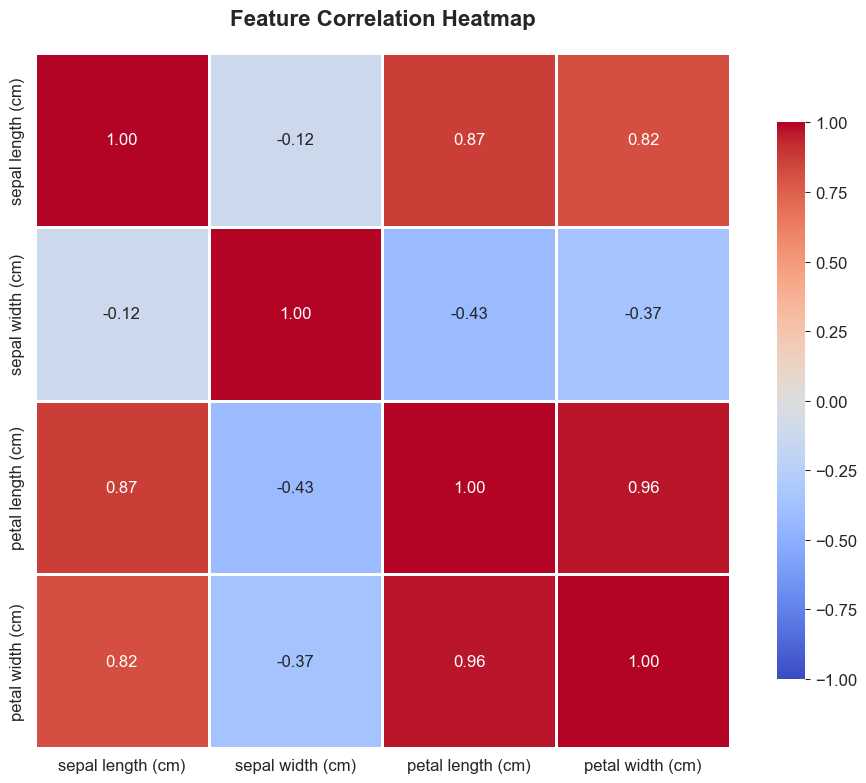

Correlation Analysis:

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  

 Key Findings:
   • Petal Length & Petal Width: HIGHLY correlated (0.96)
   • Sepal Length & Petal Length: Strongly correlated (0.87)
   • Sepal Width shows weak/negative correlation with other features


In [10]:
# VISUALIZATION 6: CORRELATION HEATMAP
# Calculate correlation matrix
correlation_matrix = df.iloc[:, :4].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=2,
    cbar_kws={'shrink': 0.8},
    vmin=-1,
    vmax=1
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Correlation Analysis:")
print("\n" + "="*70)
print(correlation_matrix)
print("="*70)

print("\n Key Findings:")
print("   • Petal Length & Petal Width: HIGHLY correlated (0.96)")
print("   • Sepal Length & Petal Length: Strongly correlated (0.87)")
print("   • Sepal Width shows weak/negative correlation with other features")

In [11]:
# ============================================================================
# DATA PREPARATION: TRAIN-TEST SPLIT
# ============================================================================

# Separate features and target
X = df.iloc[:, :4].values  # First 4 columns (features)
y = df['species'].values    # Target column

print("="*70)
print("DATA PREPARATION")
print("="*70)

print(f"\n Original Dataset:")
print(f"   • Total samples: {len(X)}")
print(f"   • Features: {X.shape[1]}")
print(f"   • Classes: {len(np.unique(y))}")

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures balanced class distribution in both sets
)

print(f"\n Train-Test Split (80-20):")
print(f"   • Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in train and test sets
print(f"\n Class Distribution in Training Set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"   • {species_mapping[cls]}: {count} samples")

print(f"\n Class Distribution in Test Set:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"   • {species_mapping[cls]}: {count} samples")

print("\n Data split completed successfully!")

DATA PREPARATION

 Original Dataset:
   • Total samples: 150
   • Features: 4
   • Classes: 3

 Train-Test Split (80-20):
   • Training samples: 120 (80.0%)
   • Testing samples: 30 (20.0%)

 Class Distribution in Training Set:
   • Setosa: 40 samples
   • Versicolor: 40 samples
   • Virginica: 40 samples

 Class Distribution in Test Set:
   • Setosa: 10 samples
   • Versicolor: 10 samples
   • Virginica: 10 samples

 Data split completed successfully!


In [12]:
# ============================================================================
# FEATURE SCALING (For algorithms like KNN, SVM)
# ============================================================================

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*70)
print("FEATURE SCALING")
print("="*70)

print("\n Why Feature Scaling?")
print("   • Algorithms like KNN and SVM are sensitive to feature scales")
print("   • StandardScaler: Transforms features to mean=0, std=1")

print("\n Before Scaling (Sample):")
print(f"   {X_train[0]}")

print("\n After Scaling (Same Sample):")
print(f"   {X_train_scaled[0]}")

print("\n Feature scaling completed!")
print("   • X_train_scaled: Shape", X_train_scaled.shape)
print("   • X_test_scaled: Shape", X_test_scaled.shape)

FEATURE SCALING

 Why Feature Scaling?
   • Algorithms like KNN and SVM are sensitive to feature scales
   • StandardScaler: Transforms features to mean=0, std=1

 Before Scaling (Sample):
   [4.4 2.9 1.4 0.2]

 After Scaling (Same Sample):
   [-1.72156775 -0.33210111 -1.34572231 -1.32327558]

 Feature scaling completed!
   • X_train_scaled: Shape (120, 4)
   • X_test_scaled: Shape (30, 4)


In [ ]:
# ============================================================================
# MODEL TRAINING: MULTIPLE ALGORITHMS
# ============================================================================

print("="*70)
print("TRAINING MACHINE LEARNING MODELS")
print("="*70)

# Dictionary to store models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB()
}

# Dictionary to store results
results = {}
trained_models = {}

# Train each model
for name, model in models.items():
    print(f"\n Training {name}...")

    # Use scaled data for KNN and SVM, regular data for others
    if name in ['K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    trained_models[name] = model

    print(f"   {name} trained successfully! Accuracy: {accuracy*100:.2f}%")

print("\n" + "="*70)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*70)

TRAINING MACHINE LEARNING MODELS

 Training Logistic Regression...
   Logistic Regression trained successfully! Accuracy: 93.33%

 Training K-Nearest Neighbors...
   K-Nearest Neighbors trained successfully! Accuracy: 93.33%

 Training Decision Tree...
   Decision Tree trained successfully! Accuracy: 93.33%

 Training Random Forest...
   Random Forest trained successfully! Accuracy: 90.00%

 Training Support Vector Machine...
   Support Vector Machine trained successfully! Accuracy: 96.67%

 Training Naive Bayes...
   Naive Bayes trained successfully! Accuracy: 96.67%

ALL MODELS TRAINED SUCCESSFULLY!



MODEL PERFORMANCE COMPARISON




,Rank,Model,Accuracy (%)
0,1,Support Vector Machine,96.666667
1,2,Naive Bayes,96.666667
2,3,K-Nearest Neighbors,93.333333
3,4,Logistic Regression,93.333333
4,5,Decision Tree,93.333333
5,6,Random Forest,90.000000


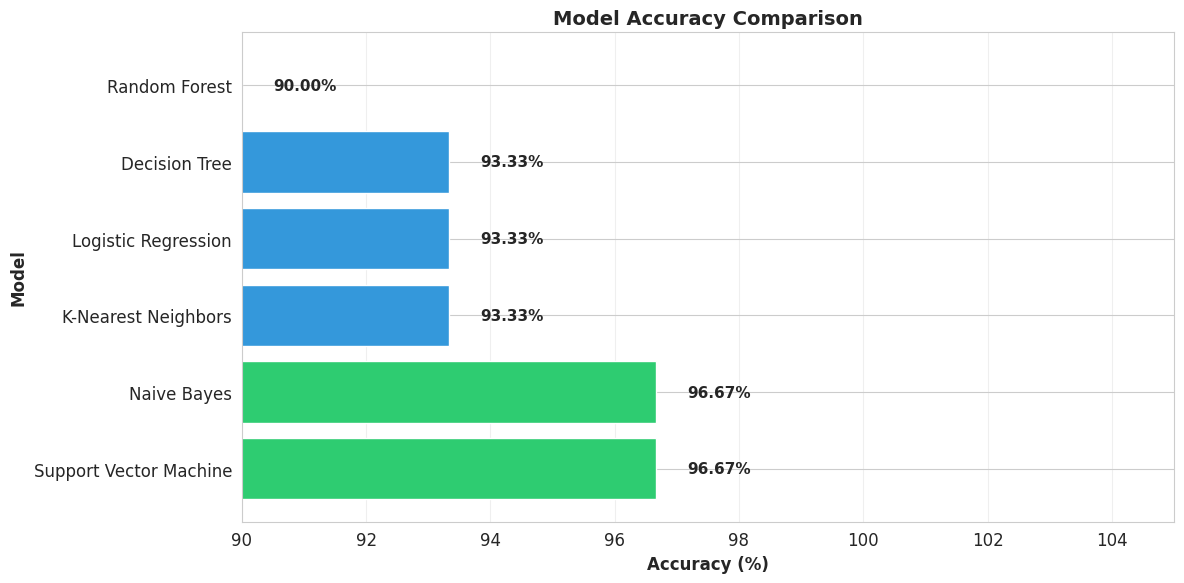


 BEST MODEL: Support Vector Machine
   Accuracy: 96.67%


In [ ]:
# ============================================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': [results[model]['accuracy']*100 for model in results.keys()]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

# Add rank
comparison_df.insert(0, 'Rank', range(1, len(comparison_df)+1))

print("\n")
display(comparison_df)

# Visualize comparison
plt.figure(figsize=(12, 6))
bars = plt.barh(
    comparison_df['Model'],
    comparison_df['Accuracy (%)'],
    color=['#2ecc71' if acc == comparison_df['Accuracy (%)'].max()
           else '#3498db' for acc in comparison_df['Accuracy (%)']]
)

plt.xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylabel('Model', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlim(90, 105)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}%',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy (%)']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.2f}%")

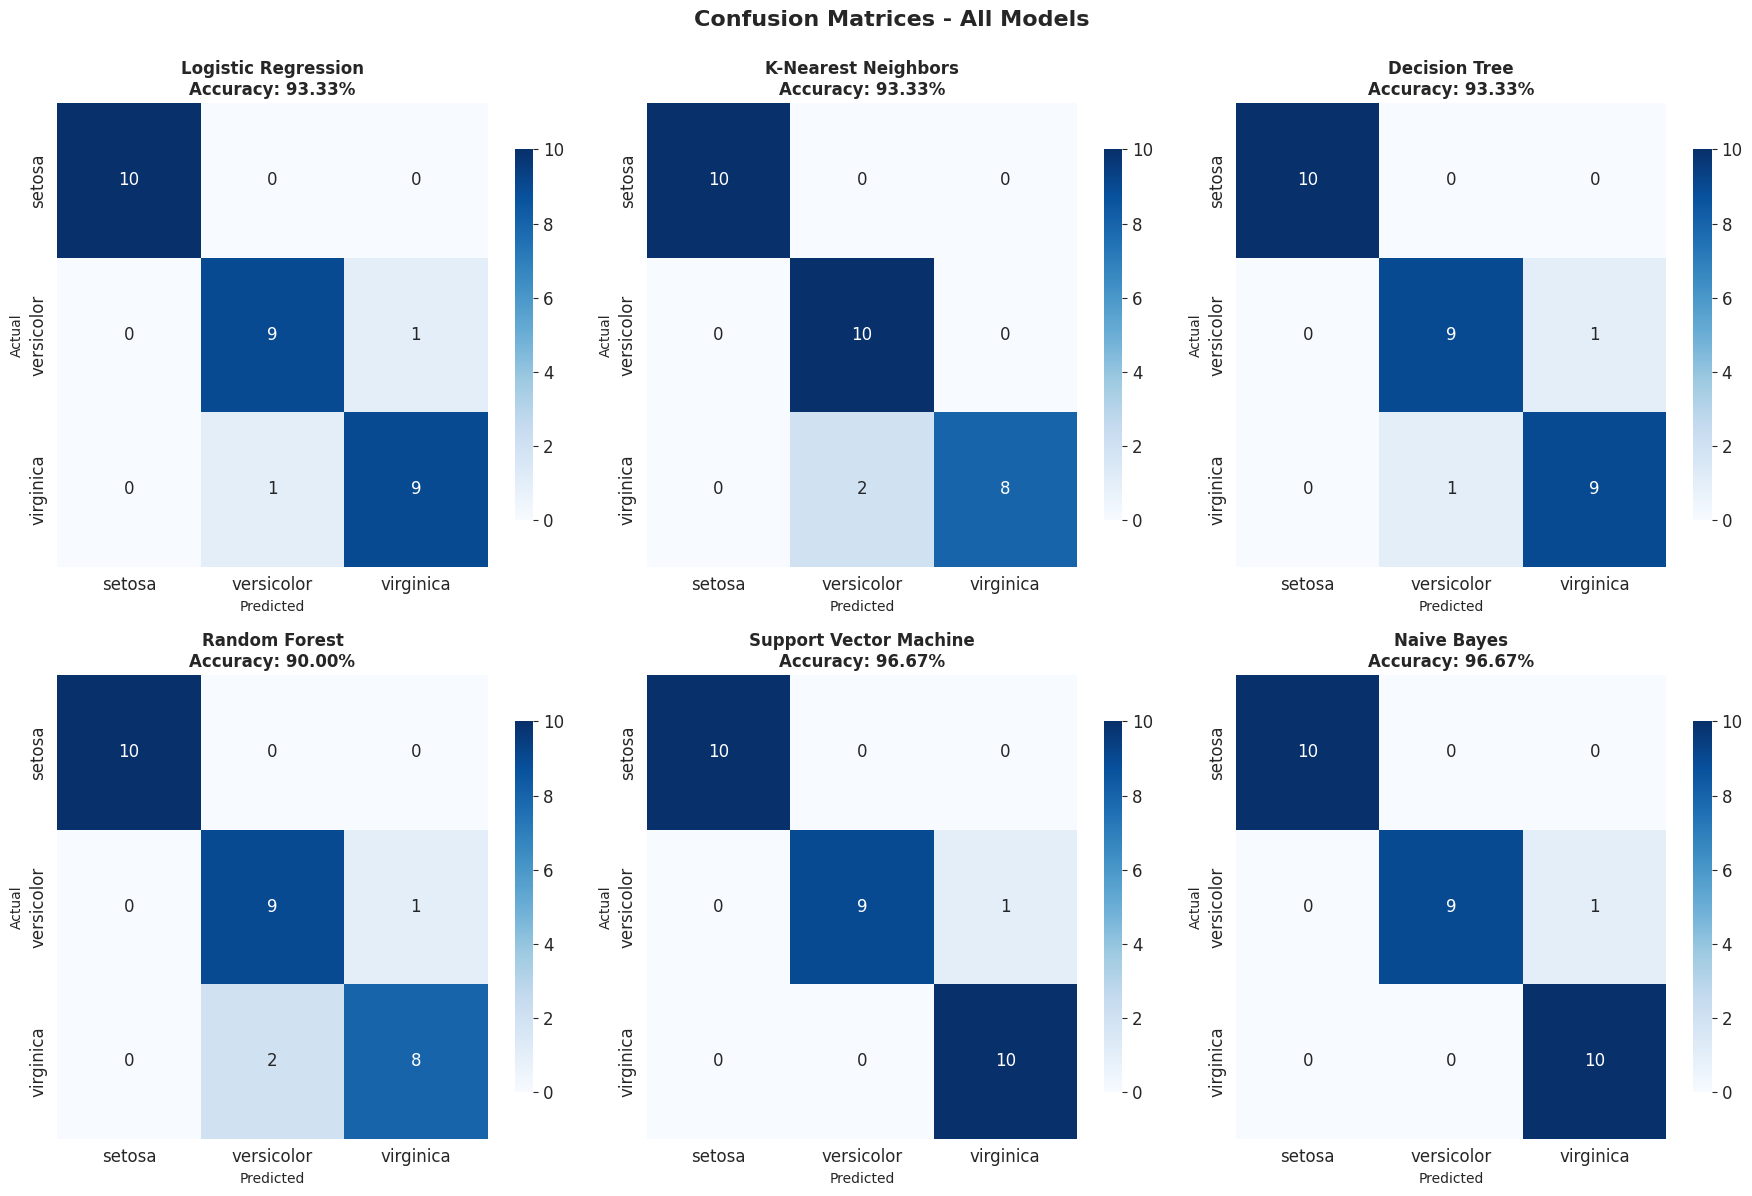

Confusion Matrix Interpretation:
   • Diagonal elements: Correct predictions
   • Off-diagonal elements: Misclassifications
   • Perfect model: All predictions on diagonal


In [ ]:
# ============================================================================
# CONFUSION MATRICES FOR ALL MODELS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, data) in enumerate(results.items()):
    y_pred = data['predictions']
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=axes[idx],
        cbar_kws={'shrink': 0.8}
    )

    axes[idx].set_title(f'{name}\nAccuracy: {data["accuracy"]*100:.2f}%',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Confusion Matrix Interpretation:")
print("   • Diagonal elements: Correct predictions")
print("   • Off-diagonal elements: Misclassifications")
print("   • Perfect model: All predictions on diagonal")

In [ ]:
# ============================================================================
# CLASSIFICATION REPORTS FOR ALL MODELS
# ============================================================================

print("="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for name, data in results.items():
    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}\n")

    y_pred = data['predictions']

    # Classification report
    report = classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names,
        digits=4
    )
    print(report)

    # Additional metrics
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Weighted Averages:")
    print(f"   • Precision: {precision:.4f}")
    print(f"   • Recall:    {recall:.4f}")
    print(f"   • F1-Score:  {f1:.4f}")

print("\n" + "="*70)
print("Metrics Explanation:")
print("   • Precision: Of predicted class X, how many were actually X?")
print("   • Recall: Of actual class X, how many did we catch?")
print("   • F1-Score: Harmonic mean of precision and recall")
print("="*70)

DETAILED CLASSIFICATION REPORTS

LOGISTIC REGRESSION

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30

Weighted Averages:
   • Precision: 0.9333
   • Recall:    0.9333
   • F1-Score:  0.9333

K-NEAREST NEIGHBORS

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30

Weighted Averages:
   • Precision: 0.9444
   • Recall:    0.9333
   • F1-S

CROSS-VALIDATION (5-Fold)

 Purpose: Get more reliable accuracy estimates
   • Splits data into 5 parts
   • Trains 5 times, each with different test fold
   • Reports mean and standard deviation

Cross-validating Logistic Regression...
Mean CV Accuracy: 95.83% (+/- 2.64%)
Cross-validating K-Nearest Neighbors...
Mean CV Accuracy: 95.83% (+/- 3.73%)
Cross-validating Decision Tree...
Mean CV Accuracy: 94.17% (+/- 2.04%)
Cross-validating Random Forest...
Mean CV Accuracy: 95.00% (+/- 1.67%)
Cross-validating Support Vector Machine...
Mean CV Accuracy: 96.67% (+/- 3.12%)
Cross-validating Naive Bayes...
Mean CV Accuracy: 95.83% (+/- 2.64%)

Cross-Validation Results Summary



,Model,Mean Accuracy (%),Std Dev (%)
0,Support Vector Machine,96.666667,3.118048
1,Logistic Regression,95.833333,2.635231
2,Naive Bayes,95.833333,2.635231
3,K-Nearest Neighbors,95.833333,3.726780
4,Random Forest,95.000000,1.666667
5,Decision Tree,94.166667,2.041241


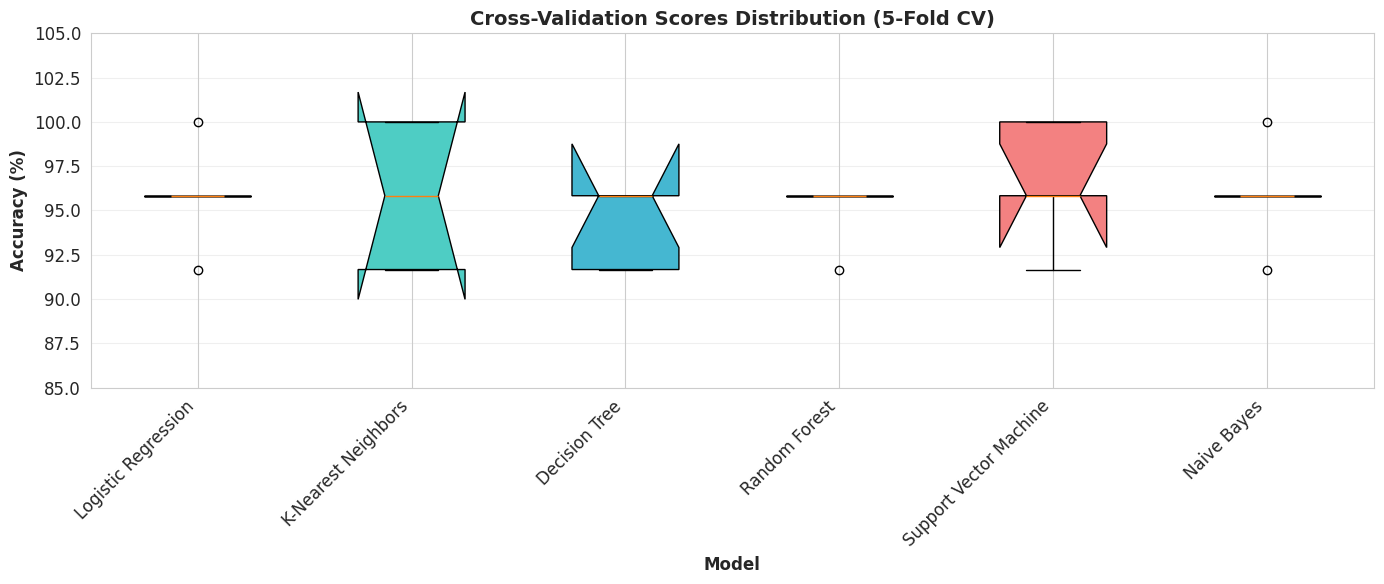


 Cross-validation completed!


In [ ]:
# ============================================================================
# CROSS-VALIDATION ANALYSIS
# ============================================================================

print("="*70)
print("CROSS-VALIDATION (5-Fold)")
print("="*70)
print("\n Purpose: Get more reliable accuracy estimates")
print("   • Splits data into 5 parts")
print("   • Trains 5 times, each with different test fold")
print("   • Reports mean and standard deviation\n")

cv_results = {}

for name, model in models.items():
    print(f"Cross-validating {name}...")

    # Use scaled data for certain models
    if name in ['K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression']:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    cv_results[name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }

    print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")

# Visualize CV results
print("\n" + "="*70)
print("Cross-Validation Results Summary")
print("="*70 + "\n")

cv_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean Accuracy (%)': [cv_results[m]['mean']*100 for m in cv_results.keys()],
    'Std Dev (%)': [cv_results[m]['std']*100 for m in cv_results.keys()]
}).sort_values('Mean Accuracy (%)', ascending=False).reset_index(drop=True)

display(cv_df)

# Plot CV scores
plt.figure(figsize=(14, 6))
positions = range(len(cv_results))
model_names = list(cv_results.keys())

bp = plt.boxplot(
    [cv_results[m]['scores']*100 for m in model_names],
    positions=positions,
    labels=model_names,
    patch_artist=True,
    notch=True,
    vert=True
)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181', '#AA96DA']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Cross-Validation Scores Distribution (5-Fold CV)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(85, 105)
plt.tight_layout()
plt.show()

print("\n Cross-validation completed!")

FEATURE IMPORTANCE ANALYSIS

 Feature Importance Rankings:



,Feature,Importance,Importance (%)
0,petal width (cm),0.437185,43.718536
1,petal length (cm),0.431466,43.146641
2,sepal length (cm),0.116349,11.634851
3,sepal width (cm),0.015000,1.499973


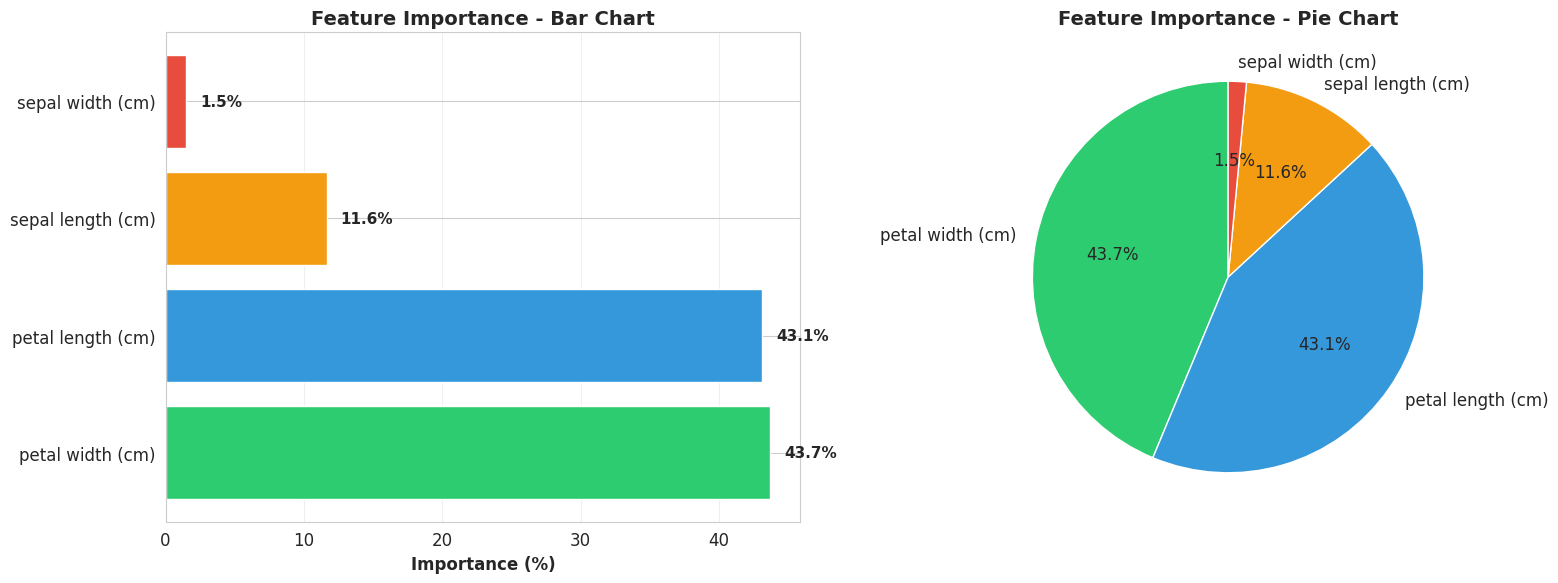


 Key Insights:
   • Most Important: petal width (cm) (43.7%)
   • Least Important: sepal width (cm) (1.5%)
   • Petal measurements are significantly more important than sepal measurements


In [ ]:
# ============================================================================
# FEATURE IMPORTANCE ANALYSIS (Random Forest)
# ============================================================================

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get Random Forest model
rf_model = trained_models['Random Forest']

# Get feature importances
importances = rf_model.feature_importances_
feature_names = iris.feature_names

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Add percentage
importance_df['Importance (%)'] = importance_df['Importance'] * 100

print("\n Feature Importance Rankings:\n")
display(importance_df)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors_importance = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = axes[0].barh(importance_df['Feature'], importance_df['Importance (%)'], color=colors_importance)
axes[0].set_xlabel('Importance (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Feature Importance - Bar Chart', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add labels
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(
    importance_df['Importance (%)'],
    labels=importance_df['Feature'],
    autopct='%1.1f%%',
    colors=colors_importance,
    startangle=90
)
axes[1].set_title('Feature Importance - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Key Insights:")
print(f"   • Most Important: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance (%)']:.1f}%)")
print(f"   • Least Important: {importance_df.iloc[-1]['Feature']} ({importance_df.iloc[-1]['Importance (%)']:.1f}%)")
print("   • Petal measurements are significantly more important than sepal measurements")

In [ ]:
# ============================================================================
# MAKING PREDICTIONS ON NEW DATA
# ============================================================================

print("="*70)
print("PREDICTION ON NEW FLOWER SAMPLES")
print("="*70)

# New flower samples (example data)
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Likely Setosa
    [6.7, 3.0, 5.2, 2.3],  # Likely Virginica
    [5.7, 2.8, 4.1, 1.3],  # Likely Versicolor
])

# Get the best model (Random Forest)
best_model = trained_models['Random Forest']

# Make predictions
predictions = best_model.predict(new_samples)
prediction_names = [iris.target_names[pred] for pred in predictions]

# If model supports probability
if hasattr(best_model, 'predict_proba'):
    probabilities = best_model.predict_proba(new_samples)
else:
    probabilities = None

# Display results
print("\n New Flower Measurements & Predictions:\n")

for i, (sample, pred_name, pred_num) in enumerate(zip(new_samples, prediction_names, predictions)):
    print(f"{'='*70}")
    print(f"Sample {i+1}:")
    print(f"{'='*70}")
    print(f"   Sepal Length: {sample[0]} cm")
    print(f"   Sepal Width:  {sample[1]} cm")
    print(f"   Petal Length: {sample[2]} cm")
    print(f"   Petal Width:  {sample[3]} cm")
    print(f"\n Predicted Species: {pred_name.upper()}")

    if probabilities is not None:
        print(f"\n Prediction Probabilities:")
        for j, species in enumerate(iris.target_names):
            print(f"      • {species}: {probabilities[i][j]*100:.2f}%")
    print()

print("="*70)
print("Predictions completed successfully!")
print("="*70)

PREDICTION ON NEW FLOWER SAMPLES

 New Flower Measurements & Predictions:

Sample 1:
   Sepal Length: 5.1 cm
   Sepal Width:  3.5 cm
   Petal Length: 1.4 cm
   Petal Width:  0.2 cm

 Predicted Species: SETOSA

 Prediction Probabilities:
      • setosa: 100.00%
      • versicolor: 0.00%
      • virginica: 0.00%

Sample 2:
   Sepal Length: 6.7 cm
   Sepal Width:  3.0 cm
   Petal Length: 5.2 cm
   Petal Width:  2.3 cm

 Predicted Species: VIRGINICA

 Prediction Probabilities:
      • setosa: 0.00%
      • versicolor: 0.00%
      • virginica: 100.00%

Sample 3:
   Sepal Length: 5.7 cm
   Sepal Width:  2.8 cm
   Petal Length: 4.1 cm
   Petal Width:  1.3 cm

 Predicted Species: VERSICOLOR

 Prediction Probabilities:
      • setosa: 0.00%
      • versicolor: 100.00%
      • virginica: 0.00%

Predictions completed successfully!


In [ ]:
# ============================================================================
# SAVE THE BEST MODEL
# ============================================================================

import pickle

# Save the Random Forest model
model_filename = 'iris_random_forest_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

print("="*70)
print("MODEL SAVED SUCCESSFULLY")
print("="*70)
print(f"\n Model saved as: {model_filename}")
print(f"Model type: {type(best_model).__name__}")
print(f"Model accuracy: {results['Random Forest']['accuracy']*100:.2f}%")

print("\n To load this model later:")
print("   ```python")
print("   with open('iris_random_forest_model.pkl', 'rb') as file:")
print("       loaded_model = pickle.load(file)")
print("   ```")

# Also save the scaler (if needed for deployment)
scaler_filename = 'iris_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"\n Scaler saved as: {scaler_filename}")
print("\n" + "="*70)

MODEL SAVED SUCCESSFULLY

 Model saved as: iris_random_forest_model.pkl
Model type: RandomForestClassifier
Model accuracy: 90.00%

 To load this model later:
   ```python
   with open('iris_random_forest_model.pkl', 'rb') as file:
       loaded_model = pickle.load(file)
   ```

 Scaler saved as: iris_scaler.pkl

